## Assignment 2

### Submission Q's

* How has the distribution of content ratings changed over time?
* Is there a relationship between content age and its type (Movie vs. TV Show)?
* Can we identify any trends in content production based on the release year vs. the year added to Netflix?
* What are the most common word pairs or phrases in content descriptions?
* Who are the top directors on Netflix?

#### 1. Importing, Loading and Inspection

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from wordcloud import WordCloud


In [32]:
data_df = pd.read_csv('data/netflix_titles.csv')
data_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [33]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


According to the above inspection we get to know that we have some missing values in `director (31%)`, `cast (9%)`, `country (7%)`, `date_added (<1%)` and `rating (<1%)` in which we have to certain steps for `director (31%)`, `cast (9%)`, `country (7%)` to fill the missing values but for `date_added (<1%)` and `rating (<1%)`, we could remove them. Along with that `date_added` is not in appropriate data type. 

#### 2. Data Cleaning and Handling Irregularities

In [34]:
# Check missing values
data_df.isnull().mean() * 100

show_id          0.000000
type             0.000000
title            0.000000
director        30.679337
cast             9.220496
country          6.510851
date_added       0.128419
release_year     0.000000
rating           0.089893
duration         0.000000
listed_in        0.000000
description      0.000000
dtype: float64

In [35]:
#Drop Rows with Very Minor Missing Data
data_df.dropna(subset=['date_added', 'rating'], inplace=True)

date_added and rating have < 1 % missing — safe to remove.

In [36]:
# Handle missing values in 'director' and 'cast'
# Since these are text fields and many are missing, we'll fill them with 'Unknown'.
data_df['cast'] = data_df['cast'].fillna('Unknown')

In [37]:
# Compute the most frequent director for each genre
mode_by_genre = (
    data_df.groupby('listed_in')['director']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')
)

# Fill missing directors by matching genre
data_df['director'] = data_df.apply(
    lambda row: mode_by_genre[row['listed_in']]
    if pd.isna(row['director']) or row['director'] == ''
    else row['director'],
    axis=1
)

In [38]:
# Handle missing 'country'
# We'll fill with the mode, which is the most common country.
mode_country = data_df['country'].mode()[0]
data_df['country'] = data_df['country'].fillna(mode_country)


In [39]:
# Convert 'date_added' to datetime objects
# Use format='mixed' to handle potential variations in date formats
data_df['date_added'] = pd.to_datetime(data_df['date_added'], format='mixed', dayfirst=False)

In [40]:
# Create new features for year and month added
data_df['year_added'] = data_df['date_added'].dt.year
data_df['month_added'] = data_df['date_added'].dt.month

In [41]:
# Verify our cleaning and transformation
print("Missing values after cleaning:")
print(data_df.isnull().sum())
print("\nData types after transformation:")
print(data_df.dtypes)

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

Data types after transformation:
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added               int32
month_added              int32
dtype: object


#### Submission Q&A

In [42]:
data_df['rating'].value_counts().sort_index()

rating
G             39
NC-17          3
NR            83
PG           247
PG-13        386
R            665
TV-14       1928
TV-G         194
TV-MA       2861
TV-PG        804
TV-Y         279
TV-Y7        270
TV-Y7-FV       6
UR             5
Name: count, dtype: int64

##### A) How has the distribution of content ratings changed over time?

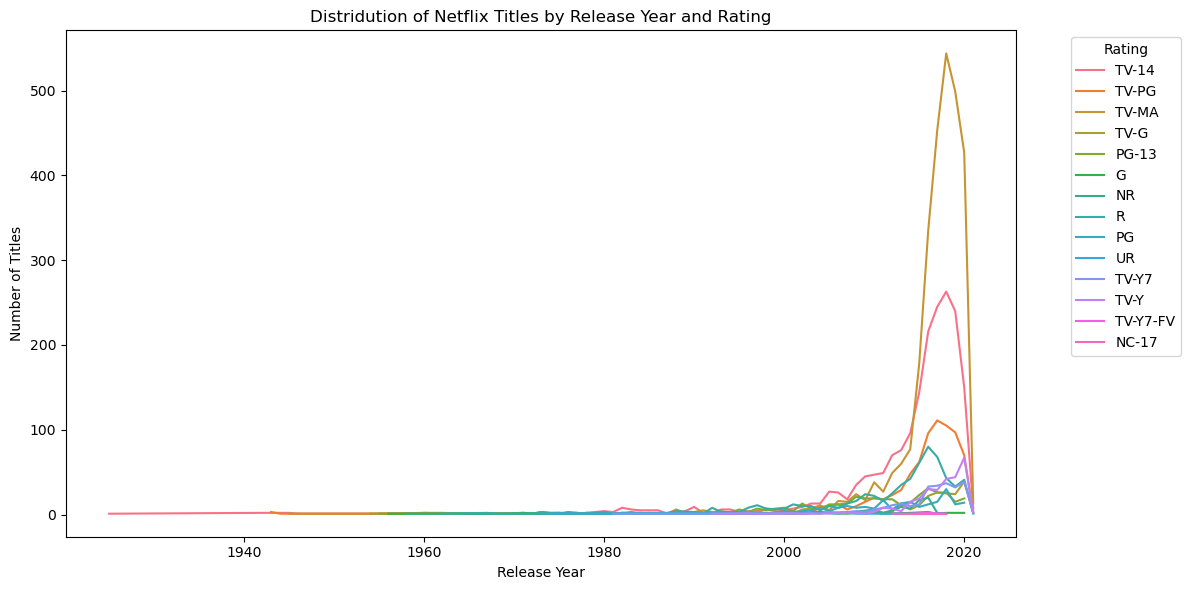

In [43]:
### Group by Release Year and Rating
# Count how many titles were released in each year per rating category.

rating_trend = (
    data_df.groupby(['release_year', 'rating'])
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=rating_trend, x='release_year', y='count', hue='rating', markers='o')
plt.title('Distridution of Netflix Titles by Release Year and Rating')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')  
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

From 1940 to 1980 the production of each title from each rating remain constant.
From 1980 to 2000 their is change int the production.
From 2000 to 2020 their is suddern rise, from which `TV-MA`, `TV-14`, `Tv-PG` are the rating under which releases are the highest

##### B) Is there a relationship between content age and its type (Movie vs. TV Show)?

In [44]:
# Age of your COntent
current_year = datetime.now().year
data_df['content_age'] = current_year - data_df['release_year']

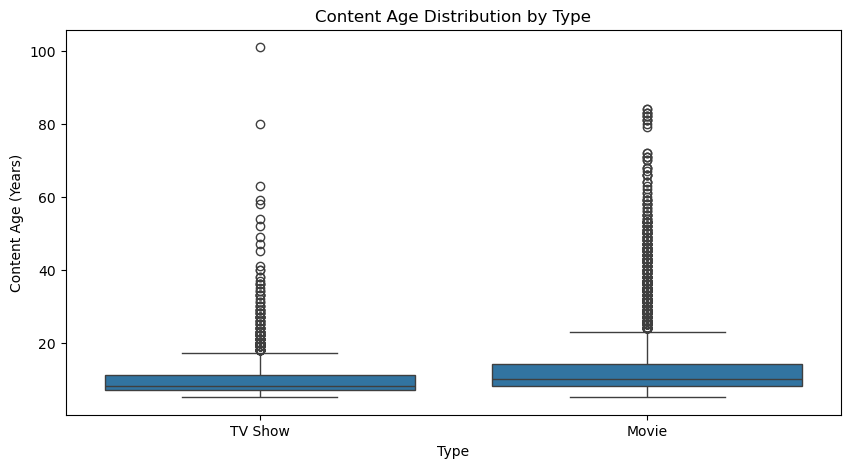

In [45]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data_df, x='type', y='content_age')
plt.title('Content Age Distribution by Type')
plt.xlabel('Type')
plt.ylabel('Content Age (Years)')
plt.show()

At most TV Show and Movies are not very old

##### C) Can we identify any trends in content production based on the release year vs. the year added to Netflix?

In [46]:
# This new column shows **how many years after release** the content was added to Netflix.
data_df['years_to_add'] = data_df['year_added'] - data_df['release_year']

In [47]:
# Average delay per year Netflix added content
delay_trend = (
    data_df.groupby('year_added')['years_to_add']
    .mean()
    .reset_index(name='avg_years_to_add')
)
delay_trend.head()

,year_added,avg_years_to_add
0,2008,1.500000
1,2009,1.000000
2,2010,23.000000
3,2011,19.923077
4,2012,1.000000


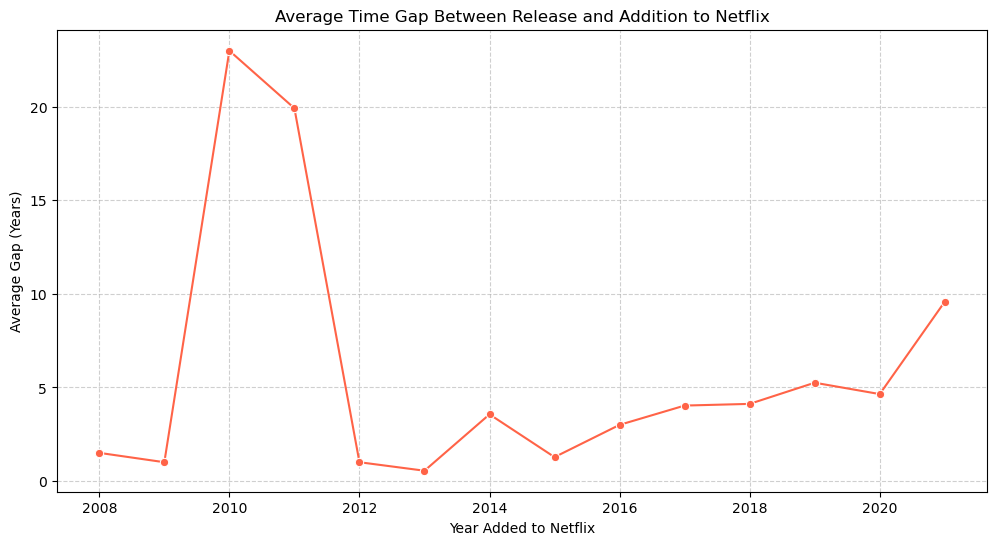

In [48]:
plt.figure(figsize=(12,6))
sns.lineplot(data=delay_trend, x='year_added', y='avg_years_to_add', marker='o', color='tomato')
plt.title('Average Time Gap Between Release and Addition to Netflix')
plt.xlabel('Year Added to Netflix')
plt.ylabel('Average Gap (Years)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

During 2005 to 2010 Netflix bought very late more from third party production houses.
From 2010 to 2012 Netfix started buying eary on.
From 2012 to 2020 Netflix bought a title before 5 Years.

##### D) What are the most common word pairs or phrases in content descriptions?


In [49]:
text = ' '.join(data_df['description'].dropna())

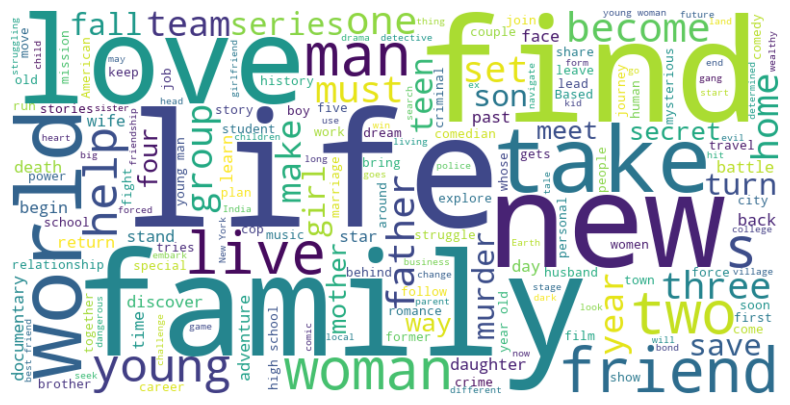

In [50]:
wordcloud = WordCloud(width=800, height=400, background_color='white', min_font_size=10).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") # Hide the axes
plt.show()

##### E) Who are the top directors on Netflix?

In [55]:
director_df = data_df.copy()
director_df['director'] = director_df['director'].str.split(', ').explode('director').str.strip()

# Remove 'Unknown' directors and missing values
director_df = director_df[director_df['director'].notna()]           # remove NaN
director_df = director_df[director_df['director'].str.lower() != 'unknown']  # remove 'Unknown'

# Count Number of Titles per Director
top_directors = (
    director_df['director']
    .value_counts()
    .reset_index(name='count')
)
top_directors


,director,count
0,Andrew Tan,165
1,Stephen Murray,164
2,Anurag Basu,84
3,Michael Simon,81
4,Ehtesham Uddin,79
...,...,...
3929,Johnny To,1
3930,Robert Tate,1
3931,Anna Migotto,1
3932,Vikram Bhatt,1


C:\Users\aksha\AppData\Local\Temp\ipykernel_10204\3347652188.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


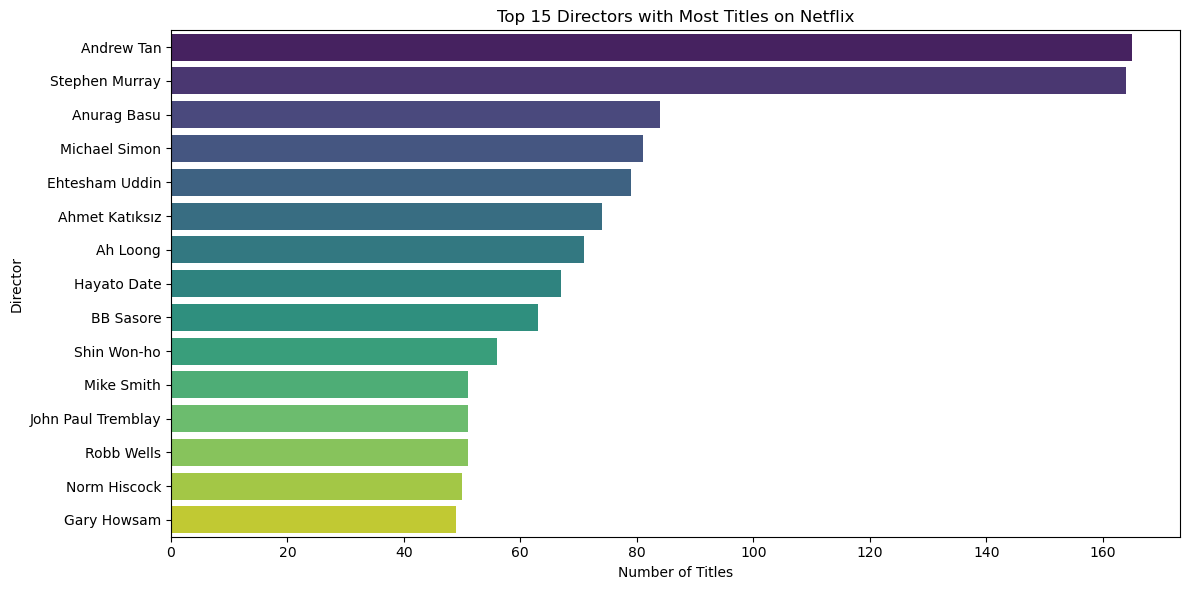

In [56]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_directors.head(15),
    x='count', y='director',
    palette='viridis'
)
plt.title('Top 15 Directors with Most Titles on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.tight_layout()
plt.show()

Andrew Tan, Stephen Murray, Anurag Basu are the TOP DIRECTORS. <br>
`NOTE : ` We have removed where director is unknown or NaN and Replace Directors name with the mode of that genere
